In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
WORK = '/kaggle/working'

def find(name):
    hits = glob.glob(f'/kaggle/input/**/{name}', recursive=True)
    assert len(hits) == 1, (name, hits)
    return hits[0]

BASE = os.path.dirname(find('train.csv'))
test = pd.read_csv(f'{BASE}/test.csv')
folds = pd.read_csv(find('folds.csv'))
fg = pd.read_csv(find('folds_group.csv'))
folds = folds.merge(fg[['uid', 'g120', 'g250']], on='uid', how='left')
assert folds[['g120', 'g250']].isna().sum().sum() == 0

te_uids = ['test/' + f for f in test.filename]
TF = pd.read_csv(find('text_features.csv'), index_col='uid')
TF_tr, TF_te = TF.loc[folds.uid], TF.loc[te_uids]

w_uids = pd.read_csv(find('wavlm_uids.csv')).uid.tolist()
Em = np.load(find('wavlm_large_mean.npy'), mmap_mode='r')
idx = {u: i for i, u in enumerate(w_uids)}
W21 = np.asarray(Em[:, 21, :], dtype=np.float32)
W_tr = W21[[idx[u] for u in folds.uid]]
W_te = W21[[idx[u] for u in te_uids]]

y = folds.label.values
w = folds.w_test.values
nz = (folds.is_zero == 0).values
grp = folds.dur_group.values
g2 = folds.dg2.values

def rmse(a, b): return float(np.sqrt(np.mean((a - b) ** 2)))
def pear(a, b): return float(np.corrcoef(a, b)[0, 1])
def wrmse(a, b, ww): return float(np.sqrt(np.sum(ww * (a - b) ** 2) / np.sum(ww)))
def wpear(a, b, ww):
    ma, mb = np.average(a, weights=ww), np.average(b, weights=ww)
    return float(np.sum(ww * (a - ma) * (b - mb)) /
                 np.sqrt(np.sum(ww * (a - ma) ** 2) * np.sum(ww * (b - mb) ** 2)))

def report(oof):
    r = {'non_zero': (rmse(y[nz], oof[nz]), pear(y[nz], oof[nz]))}
    for g in ['dur_45s', 'dur_60s']:
        m = nz & (grp == g)
        r[g] = (rmse(y[m], oof[m]), pear(y[m], oof[m]))
    r['test_weighted'] = (wrmse(y[nz], oof[nz], w[nz]), wpear(y[nz], oof[nz], w[nz]))
    return pd.DataFrame(r, index=['RMSE', 'Pearson']).T.round(4)

def score(oof):
    r = report(oof)
    rm, pe = r.loc['test_weighted', 'RMSE'], r.loc['test_weighted', 'Pearson']
    return dict(rmse_w=rm, pear_w=pe, proxy=(rm + 1 - pe) / 2,
                pear_45=r.loc['dur_45s', 'Pearson'], pear_60=r.loc['dur_60s', 'Pearson'])

print('train rows:', len(folds), '| non-zero:', int(nz.sum()), '| test rows:', len(test))
print('text features:', TF.shape, '| wavlm layer 21:', W21.shape)
print(folds.groupby('dg2').size().to_dict())

train rows: 769 | non-zero: 732 | test rows: 216
text features: (985, 74) | wavlm layer 21: (985, 1024)
{'g45': 187, 'g60': 582}


In [2]:
# S2: base models aur ablation
class Winsor(BaseEstimator, TransformerMixin):
    def __init__(self, lo=1, hi=99):
        self.lo, self.hi = lo, hi
    def fit(self, X, y=None):
        self.lo_ = np.percentile(X, self.lo, axis=0)
        self.hi_ = np.percentile(X, self.hi, axis=0)
        return self
    def transform(self, X):
        return np.clip(X, self.lo_, self.hi_)

def ridge_emb():
    return make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(1, 5, 9)))

def ridge_text():
    return make_pipeline(SimpleImputer(strategy='median'), Winsor(), StandardScaler(),
                         RidgeCV(alphas=np.logspace(-1, 4, 12)))

def lgb_text():
    return lgb.LGBMRegressor(n_estimators=400, learning_rate=0.03, num_leaves=7, min_child_samples=20,
                             subsample=0.8, subsample_freq=1, colsample_bytree=0.5, reg_lambda=5.0,
                             random_state=42, verbose=-1)

FOLD_COLS = ['g250', 'g120']
R, rows = {}, []

def run(name, X_tr, X_te, make_model):
    X_tr, X_te = np.asarray(X_tr, dtype=np.float32), np.asarray(X_te, dtype=np.float32)
    oof = {}
    for col in FOLD_COLS:
        o = np.full(len(y), np.nan)
        for f in range(5):
            va = (folds[col] == f).values
            m = make_model().fit(X_tr[(~va) & nz], y[(~va) & nz])
            o[va & nz] = np.clip(m.predict(X_tr[va & nz]), 1, 5)
        oof[col] = o
    m = make_model().fit(X_tr[nz], y[nz])
    R[name] = dict(oof=oof, test=np.clip(m.predict(X_te), 1, 5))
    s, s2 = score(oof['g250']), score(oof['g120'])
    tr_rmse = rmse(y[nz], np.clip(m.predict(X_tr[nz]), 1, 5))
    return dict(model=name, proxy_g250=s['proxy'], proxy_g120=s2['proxy'], rmse_w=s['rmse_w'],
                pear_w=s['pear_w'], pear_45=s['pear_45'], pear_60=s['pear_60'], train_rmse=tr_rmse)

cols = TF.columns.tolist()
conf = [c for c in cols if c.startswith(('wp_', 'seg_logprob', 'max_no_speech'))]
noconf = [c for c in cols if c not in conf]
print('text features:', len(cols), '| ASR-confidence group:', len(conf), '| without it:', len(noconf))

rows.append(run('wavlm_L21_ridge', W_tr, W_te, ridge_emb))
rows.append(run('text_all_ridge', TF_tr[cols], TF_te[cols], ridge_text))
rows.append(run('text_all_lgb', TF_tr[cols], TF_te[cols], lgb_text))
rows.append(run('text_noconf_ridge', TF_tr[noconf], TF_te[noconf], ridge_text))
rows.append(run('text_noconf_lgb', TF_tr[noconf], TF_te[noconf], lgb_text))

tab = pd.DataFrame(rows).round(4)
print(tab.sort_values('proxy_g250').to_string(index=False))

# integrity check against notebook 5
base = R['wavlm_L21_ridge']
sv = pd.read_csv(find('test_wavlm_L21.csv')).set_index('filename').pred.reindex(test.filename).values
print('\ntest preds vs notebook 5: corr', round(pear(sv, base['test']), 5),
      '| max abs diff', round(float(np.abs(sv - base['test']).max()), 5))
so = pd.read_csv(find('oof_wavlm_g250.csv')).set_index('uid').oof_g250.reindex(folds.uid).values
print('oof vs notebook 5: max abs diff', round(float(np.nanmax(np.abs(so - base['oof']['g250']))), 5))

text features: 74 | ASR-confidence group: 12 | without it: 62
            model  proxy_g250  proxy_g120  rmse_w  pear_w  pear_45  pear_60  train_rmse
  wavlm_L21_ridge      0.4184      0.4309  0.6125  0.7758   0.7329   0.8271      0.3873
   text_all_ridge      0.5150      0.5065  0.7119  0.6818   0.6370   0.7359      0.6522
     text_all_lgb      0.5414      0.5314  0.7349  0.6521   0.5699   0.7296      0.3822
text_noconf_ridge      0.5822      0.5669  0.7723  0.6078   0.5616   0.6505      0.7256
  text_noconf_lgb      0.6292      0.6180  0.8110  0.5525   0.4662   0.6162      0.4510

test preds vs notebook 5: corr 1.0 | max abs diff 0.0
oof vs notebook 5: max abs diff 0.0


test group sizes: {'g45': 150, 'g60': 66}
                        blend  proxy_g250  proxy_g120  rmse_w  pear_w  pear_45  pear_60  proxy_mean
      A_wavlm+text_all|global      0.4000      0.4102  0.5921  0.7921   0.7527   0.8359      0.4051
            C_all_five|global      0.4026      0.4107  0.5949  0.7897   0.7495   0.8347      0.4066
   A_wavlm+text_all|per_group      0.4021      0.4166  0.5932  0.7890   0.7433   0.8350      0.4094
   B_wavlm+text_noconf|global      0.4041      0.4179  0.5964  0.7882   0.7478   0.8317      0.4110
         C_all_five|per_group      0.4118      0.4194  0.6039  0.7803   0.7289   0.8343      0.4156
B_wavlm+text_noconf|per_group      0.4108      0.4223  0.6027  0.7812   0.7319   0.8312      0.4166

best blend by CV: A_wavlm+text_all|global
                 RMSE  Pearson
non_zero       0.5748   0.8237
dur_45s        0.6032   0.7527
dur_60s        0.5652   0.8359
test_weighted  0.5921   0.7921
 group None weights {'wavlm_L21_ridge': np.float64(0.759), '

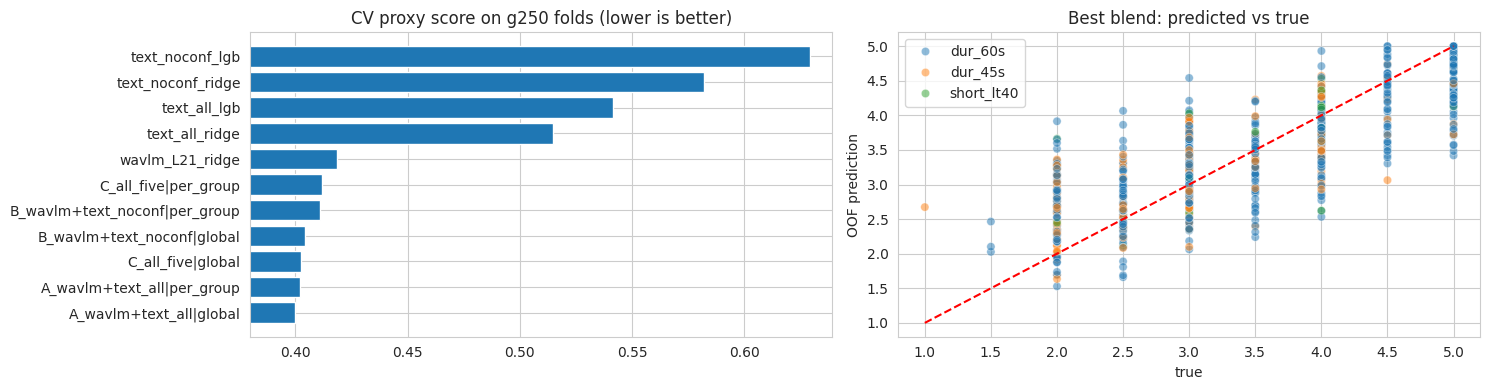

saved submission_blend.csv


In [3]:
# S3: blends, final model aur submission file
te_dur = pd.read_csv(find('audio_meta.csv')).set_index('uid').duration.reindex(te_uids).values
te_g2 = np.where(te_dur >= 52, 'g60', 'g45')
print('test group sizes:', pd.Series(te_g2).value_counts().to_dict())

def blend_cv(names, col, per_group, alpha=1.0):
    P = np.column_stack([R[n]['oof'][col] for n in names])
    out = np.full(len(y), np.nan)
    for f in range(5):
        va = (folds[col] == f).values
        for g in ([None] if not per_group else ['g45', 'g60']):
            s_tr = (~va) & nz if g is None else (~va) & nz & (g2 == g)
            s_va = va & nz if g is None else va & nz & (g2 == g)
            m = Ridge(alpha=alpha, positive=True).fit(P[s_tr], y[s_tr])
            out[s_va] = np.clip(m.predict(P[s_va]), 1, 5)
    return out

def blend_fit_predict(names, per_group, alpha=1.0, col='g250'):
    P = np.column_stack([R[n]['oof'][col] for n in names])
    T = np.column_stack([R[n]['test'] for n in names])
    out = np.zeros(len(T))
    for g in ([None] if not per_group else ['g45', 'g60']):
        sel = nz if g is None else nz & (g2 == g)
        selt = np.ones(len(T), bool) if g is None else (te_g2 == g)
        m = Ridge(alpha=alpha, positive=True).fit(P[sel], y[sel])
        out[selt] = m.predict(T[selt])
        print(' group', g, 'weights', dict(zip(names, np.round(m.coef_, 3))), 'intercept', round(float(m.intercept_), 3))
    return np.clip(out, 1, 5)

combos = {
    'A_wavlm+text_all': ['wavlm_L21_ridge', 'text_all_ridge', 'text_all_lgb'],
    'B_wavlm+text_noconf': ['wavlm_L21_ridge', 'text_noconf_ridge', 'text_noconf_lgb'],
    'C_all_five': ['wavlm_L21_ridge', 'text_all_ridge', 'text_all_lgb', 'text_noconf_ridge', 'text_noconf_lgb'],
}
res, BL = [], {}
for cname, names in combos.items():
    for pg in [False, True]:
        key = f'{cname}|{"per_group" if pg else "global"}'
        o = {col: blend_cv(names, col, pg) for col in FOLD_COLS}
        BL[key] = (names, pg, o)
        s, s2 = score(o['g250']), score(o['g120'])
        res.append(dict(blend=key, proxy_g250=s['proxy'], proxy_g120=s2['proxy'], rmse_w=s['rmse_w'],
                        pear_w=s['pear_w'], pear_45=s['pear_45'], pear_60=s['pear_60']))
res = pd.DataFrame(res).round(4)
res['proxy_mean'] = ((res.proxy_g250 + res.proxy_g120) / 2).round(4)
print(res.sort_values('proxy_mean').to_string(index=False))

best_key = res.sort_values('proxy_mean').iloc[0].blend
names, pg, o = BL[best_key]
print('\nbest blend by CV:', best_key)
print(report(o['g250']))
pred_te = blend_fit_predict(names, pg)
print('test pred summary:', pd.Series(pred_te).describe().round(3).to_dict())
print('corr with wavlm-only test preds:', round(pear(pred_te, base['test']), 4))

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
allp = pd.concat([tab[['model', 'proxy_g250']].rename(columns={'model': 'name'}),
                  res[['blend', 'proxy_g250']].rename(columns={'blend': 'name'})]).sort_values('proxy_g250')
ax[0].barh(allp.name, allp.proxy_g250)
ax[0].set_xlim(allp.proxy_g250.min() - 0.02, allp.proxy_g250.max() + 0.01)
ax[0].set_title('CV proxy score on g250 folds (lower is better)')
sns.scatterplot(x=y[nz], y=o['g250'][nz], hue=grp[nz], alpha=0.5, ax=ax[1])
ax[1].plot([1, 5], [1, 5], 'r--'); ax[1].set_xlabel('true'); ax[1].set_ylabel('OOF prediction')
ax[1].set_title('Best blend: predicted vs true')
plt.tight_layout(); plt.show()

pd.DataFrame({'uid': folds.uid, 'oof': o['g250']}).to_csv(f'{WORK}/oof_blend_g250.csv', index=False)
pd.DataFrame({'filename': test.filename, 'label': pred_te}).to_csv(f'{WORK}/submission_blend.csv', index=False)
print('saved submission_blend.csv')